In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime as dt
df_org_PQ = pd.read_excel(r'C:\Users\micha\Documents\Projets_Abschlussarbeit\Proj_Machine-Log-Navigator\MLN-normalized\PrintQuality.xlsx')

pd.set_option('display.max_columns', None)

head = df_org_PQ.head(20)
samples = df_org_PQ.sample(10)
describe_all = df_org_PQ.describe(include='all').round(2)
describe_figures = df_org_PQ.describe()

print("\n>>> HEAD: ")
display(head)
print("\n\n>>> DF INFO: ")
df_org_PQ.info()



>>> HEAD: 


,Time,Shipment,SlamPrinter,PrintQuality
0,"00:02:28,196",Sp260318090057,SLAM5_LP1,100.00
1,"00:03:09,187",Sp260318090060,SLAM5_LP2,99.97
2,"00:03:21,232",Sp260318090061,SLAM5_LP1,99.91
3,"00:03:33,458",Sp260318090062,SLAM5_LP2,99.88
4,"00:03:47,883",Sp260318090063,SLAM5_LP1,99.82
5,"00:04:02,414",Sp260318090064,SLAM5_LP2,99.79
6,"00:04:15,666",Sp260318090065,SLAM5_LP1,99.74
7,"00:04:28,514",Sp260318090066,SLAM5_LP2,99.71
8,"00:04:41,721",Sp260318090067,SLAM5_LP1,99.65
9,"00:04:56,127",Sp260318090068,SLAM5_LP2,99.62




>>> DF INFO: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4456 entries, 0 to 4455
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Time          4456 non-null   object 
 1   Shipment      4456 non-null   object 
 2   SlamPrinter   4456 non-null   object 
 3   PrintQuality  4456 non-null   float64
dtypes: float64(1), object(3)
memory usage: 139.4+ KB


In [2]:
# 1) umwandeln in Pandas-Zeitwert von Format 'O' in <M8[ms]
df_org_PQ['Time'] = pd.to_datetime(df_org_PQ['Time'])

# 2) Milliselunden entfernen. Format von: <M8[ms] auf: <M8[s]
df_org_PQ['Time'] = df_org_PQ['Time'].astype('datetime64[s]')

df_org_PQ['Time'].dtype


C:\Users\micha\AppData\Local\Temp\ipykernel_11868\2444263467.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_org_PQ['Time'] = pd.to_datetime(df_org_PQ['Time'])


dtype('<M8[s]')

In [3]:
# prüfen, ob in Spalte 'SlamPrinter' die beiden Drucker auch wirklich immer zeilenweise abwechselnd vorkommen
is_alternating = (df_org_PQ['SlamPrinter'] != df_org_PQ['SlamPrinter'].shift()).all()
is_alternating


True

In [4]:
# Spalte Shipments entfernen, wird nicht mehr gebraucht
df_org_PQ = df_org_PQ.drop(columns=["Shipment"])

# Spalte PrintQuality umbennenn in verständlicher Prozessbeschreibung
df_org_PQ.rename(columns={'PrintQuality': 'Tonerstatus_beforePrint'}, inplace=True)

# Tonerstatus nach Druckvorgang in gleiche Zeile übernehmen, sowie Umbennennung für Prozessbschreibung
df_org_PQ['Tonerstatus_afterPrint'] = df_org_PQ['Tonerstatus_beforePrint'].shift(-1)

# Tonerverbrauch anzeigen
df_org_PQ['ink_usage'] = df_org_PQ['Tonerstatus_beforePrint'] - df_org_PQ['Tonerstatus_afterPrint']

df_org_PQ.head(20)


,Time,SlamPrinter,Tonerstatus_beforePrint,Tonerstatus_afterPrint,ink_usage
0,2026-04-24 00:02:28,SLAM5_LP1,100.00,99.97,0.03
1,2026-04-24 00:03:09,SLAM5_LP2,99.97,99.91,0.06
2,2026-04-24 00:03:21,SLAM5_LP1,99.91,99.88,0.03
3,2026-04-24 00:03:33,SLAM5_LP2,99.88,99.82,0.06
4,2026-04-24 00:03:47,SLAM5_LP1,99.82,99.79,0.03
5,2026-04-24 00:04:02,SLAM5_LP2,99.79,99.74,0.05
6,2026-04-24 00:04:15,SLAM5_LP1,99.74,99.71,0.03
7,2026-04-24 00:04:28,SLAM5_LP2,99.71,99.65,0.06
8,2026-04-24 00:04:41,SLAM5_LP1,99.65,99.62,0.03
9,2026-04-24 00:04:56,SLAM5_LP2,99.62,99.56,0.06


In [5]:
# Datensatz anschauen, Verhalten in Spalte ink-usage verstehen
df_org_PQ.describe()


,Time,Tonerstatus_beforePrint,Tonerstatus_afterPrint,ink_usage
count,4456,4456.000000,4455.000000,4455.000000
mean,2026-04-24 11:24:41,94.065902,94.064570,0.000536
min,2026-04-24 00:02:28,88.010000,88.010000,-11.990000
25%,2026-04-24 05:32:16,91.040000,91.040000,0.030000
50%,2026-04-24 11:11:24,94.080000,94.080000,0.040000
75%,2026-04-24 16:51:34,97.110000,97.110000,0.060000
max,2026-04-24 23:59:00,100.000000,100.000000,0.060000
std,NaN,3.493626,3.492886,0.720075


In [6]:
# Werte in Spalte 'ink_usage' runden und visuell prüfen was es in der Spalte an Werten gibt
df_org_PQ["ink_usage"] = round(df_org_PQ["ink_usage"],3)
df_org_PQ['ink_usage'].value_counts()


ink_usage
 0.03     1948
 0.06     1396
 0.05      823
 0.04      272
-11.99      16
Name: count, dtype: int64

In [7]:
# Alle Werte -11.99 anzeigen, um diese Ausreißer einzusehen und für Angeichung an die anderen Werte vorzubereiten
df_org_PQ_check = df_org_PQ[df_org_PQ["ink_usage"] <= -11.98]
df_org_PQ_check


,Time,SlamPrinter,Tonerstatus_beforePrint,Tonerstatus_afterPrint,ink_usage
274,2026-04-24 01:23:03,SLAM5_LP1,88.01,100.0,-11.99
549,2026-04-24 02:43:54,SLAM5_LP2,88.01,100.0,-11.99
824,2026-04-24 04:07:17,SLAM5_LP1,88.01,100.0,-11.99
1099,2026-04-24 05:28:43,SLAM5_LP2,88.01,100.0,-11.99
1374,2026-04-24 07:01:41,SLAM5_LP1,88.01,100.0,-11.99
1649,2026-04-24 08:20:58,SLAM5_LP2,88.01,100.0,-11.99
1924,2026-04-24 09:43:45,SLAM5_LP1,88.01,100.0,-11.99
2199,2026-04-24 11:03:35,SLAM5_LP2,88.01,100.0,-11.99
2474,2026-04-24 12:21:37,SLAM5_LP1,88.01,100.0,-11.99
2749,2026-04-24 13:41:35,SLAM5_LP2,88.01,100.0,-11.99


In [8]:
# alle Ausreißer mit -11.9 jetzt als Mittelwerte der jeweiligen SlamPrinter festlegen
means = df_org_PQ[df_org_PQ['ink_usage'] > -11.98].groupby('SlamPrinter')['ink_usage'].mean()
df_org_PQ['ink_usage'] = df_org_PQ.apply(
    lambda row: means[row['SlamPrinter']] if row['ink_usage'] <= -11.98 else row['ink_usage'],
    axis=1
)
print(df_org_PQ[df_org_PQ["ink_usage"] <= -11.98])
# Prüfung sollte jetzt eine Leere Liste ergeben

Empty DataFrame
Columns: [Time, SlamPrinter, Tonerstatus_beforePrint, Tonerstatus_afterPrint, ink_usage]
Index: []


In [9]:
# Werte in Spalte 'ink_usage' nach Änderung noch einmal prüfen
df_org_PQ['ink_usage'].value_counts()
# die 16 Werte von -11.9 sind jetzt aufgeteilt in jeweils 8 Werte pro SlamPrinter seiner Mittelwerte


ink_usage
0.030000    1948
0.060000    1396
0.050000     823
0.040000     272
0.031225       8
0.056291       8
Name: count, dtype: int64

In [19]:
# Datensatz in skalierbarere Größe bringen, um grafisch darstellen zu können.
# Reduzierung von 4456 auf 96 über Mittelwertbildung von 'ink_usage' über die jeweiligen SlamPrinter im Zeitfenster von 30 Minuten
df_org_PQ = df_org_PQ.groupby([pd.Grouper(key='Time', freq='60min'), 'SlamPrinter'])['ink_usage'].mean().reset_index()
df_org_PQ.head(20)


,Time,SlamPrinter,ink_usage
0,2026-04-24 00:00:00,SLAM5_LP1,0.030000
1,2026-04-24 00:00:00,SLAM5_LP2,0.057526
2,2026-04-24 01:00:00,SLAM5_LP1,0.031615
3,2026-04-24 01:00:00,SLAM5_LP2,0.055922
4,2026-04-24 02:00:00,SLAM5_LP1,0.031770
5,2026-04-24 02:00:00,SLAM5_LP2,0.055763
6,2026-04-24 03:00:00,SLAM5_LP1,0.030000
7,2026-04-24 03:00:00,SLAM5_LP2,0.057501
8,2026-04-24 04:00:00,SLAM5_LP1,0.032292
9,2026-04-24 04:00:00,SLAM5_LP2,0.055196


In [20]:
# Dataframe Metadaten anschauen ob alles funktioniert hat
df_org_PQ.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype        
---  ------       --------------  -----        
 0   Time         48 non-null     datetime64[s]
 1   SlamPrinter  48 non-null     object       
 2   ink_usage    48 non-null     float64      
dtypes: datetime64[s](1), float64(1), object(1)
memory usage: 1.3+ KB


In [21]:
# labelTime = df_org_PQ['Time'].isoformat()
labelTime = df_org_PQ['Time'].dt.strftime("%H:%M")
labelTime

0     00:00
1     00:00
2     01:00
3     01:00
4     02:00
5     02:00
6     03:00
7     03:00
8     04:00
9     04:00
10    05:00
11    05:00
12    06:00
13    06:00
14    07:00
15    07:00
16    08:00
17    08:00
18    09:00
19    09:00
20    10:00
21    10:00
22    11:00
23    11:00
24    12:00
25    12:00
26    13:00
27    13:00
28    14:00
29    14:00
30    15:00
31    15:00
32    16:00
33    16:00
34    17:00
35    17:00
36    18:00
37    18:00
38    19:00
39    19:00
40    20:00
41    20:00
42    21:00
43    21:00
44    22:00
45    22:00
46    23:00
47    23:00
Name: Time, dtype: object

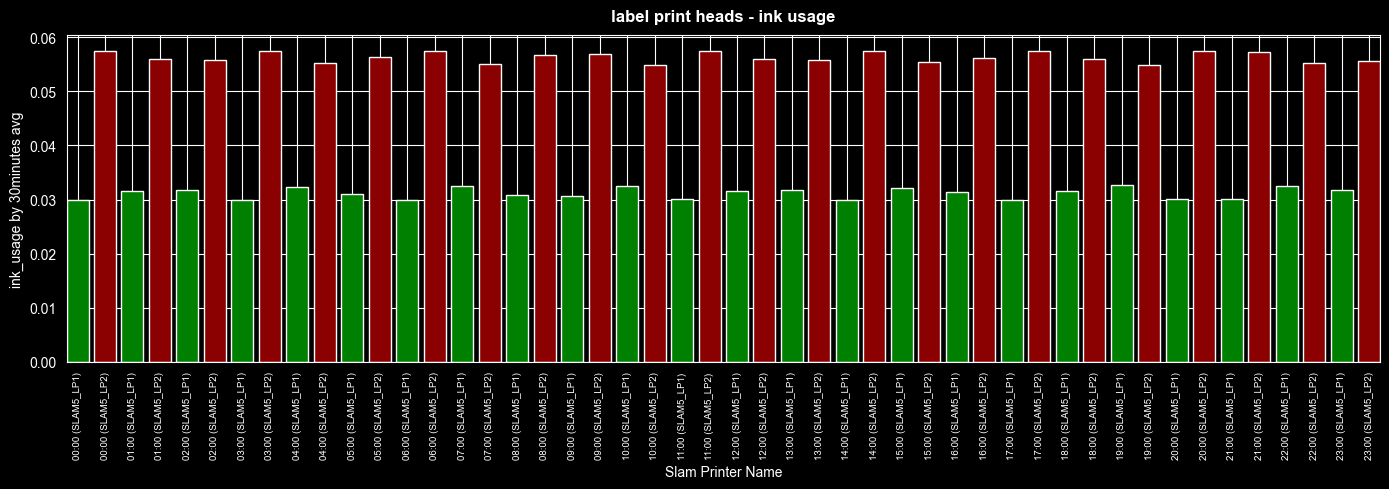

In [22]:
import matplotlib.pyplot as plt

max_val = df_org_PQ['ink_usage'].max()
color_define = {
    'SLAM5_LP1': 'green',
    'SLAM5_LP2': 'darkred'
}

barcolor = df_org_PQ['SlamPrinter'].map(color_define)
labels_x = df_org_PQ['Time'].dt.strftime("%H:%M") + " (" + df_org_PQ['SlamPrinter'] + ")"

plt.figure(figsize=(14,5))

plt.bar(range(len(df_org_PQ)), df_org_PQ['ink_usage'], color=barcolor)
plt.xticks(range(len(df_org_PQ)), labels_x, rotation=90, fontsize=7)

plt.margins(x=-0)
plt.xlabel('Slam Printer Name')
plt.ylabel('ink_usage by 30minutes avg')
plt.title("label print heads - ink usage",fontweight="bold",fontsize=12,pad=10)

plt.tight_layout()
plt.show()


In [ ]:
# für KPI-Erstellung Werte der beiden Drucker konsolieren als Mittelwerte
df_avg_report = df_org_PQ.groupby('SlamPrinter', as_index=False)['ink_usage'].mean()
df_avg_report


In [ ]:
KPI_PrintHeadNozzles = round((df_avg_report['ink_usage'].iloc[1] - df_avg_report['ink_usage'].iloc[0]) / df_avg_report['ink_usage'].iloc[0] * 100,1 )

print(f"\nALARM (!) Handlungsempfehlung Labelprintköpfe:\n>>> Slam-Printer 'SLAM5_LP2' Druckkopfdüsen prüfen da --> {KPI_PrintHeadNozzles}% höherer Verbrauch der Tonerfarbe als Slam-Printer 'SLAM1_LP1' innerhalb der letzten 24h !\n\n")
